# 05 · Attention, Transformers and Text Generation

**Contents**

1. Language modelling: the objective
2. Tokenisation: byte-pair encoding (BPE)
3. Attention as a soft dictionary lookup
4. Why divide by $\sqrt{d_k}$ (derivation)
5. Self-attention in matrix form, and why it needs positions (proof)
6. Causal masking
7. Multi-head attention and positional encodings
8. The transformer block and GPT (with a parameter count)
9. A tiny GPT, trained from scratch
10. Decoding: greedy, temperature, top-k, top-p, beam search
11. Encoders, decoders and modern LLMs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0); torch.manual_seed(0)

## 1. Language modelling

A **language model** assigns a probability to a sequence of tokens $w_1,\dots,w_T$. By the **chain rule of probability** (just repeated use of $P(A,B) = P(A)P(B\mid A)$), any joint distribution factorises as

$$
P(w_1,\dots,w_T) = \prod_{t=1}^T P(w_t\mid w_1,\dots,w_{t-1}).
$$

So it is enough to learn one thing: the distribution of the **next token given the previous ones**. That is a $|V|$-class classification problem (notebook 00 / ML notes 04). The network outputs logits $\mathbf{z}_t\in\mathbb{R}^{|V|}$, $P(w_{t+1}\mid w_{\le t}) = \mathrm{softmax}(\mathbf{z}_t)$, and training minimises the **cross-entropy** of the actual next token, i.e. maximum likelihood on the text:

$$
J(\boldsymbol{\theta}) = -\frac{1}{T}\sum_{t=1}^{T}\log P_{\boldsymbol{\theta}}(w_t\mid w_{<t}).
$$

This is **self-supervised**: the labels are the text itself, shifted by one, so any amount of raw text is training data. The usual reported metric is the **perplexity** $\exp(J)$: the effective number of tokens the model is "choosing between". A uniform guess over $|V|$ tokens has perplexity $|V|$.

Generating text = repeatedly predicting a distribution for the next token, choosing a token (section 10), appending it, and repeating (**autoregressive** generation).

## 2. Tokenisation: byte-pair encoding

Word-level vocabularies are huge and can't handle new words; character-level sequences are very long. **BPE** (used by GPT-2) finds sub-words:

1. Start with a vocabulary of single characters (bytes).
2. Count all adjacent pairs of symbols in the corpus; **merge the most frequent pair** into a new symbol.
3. Repeat until the vocabulary has the desired size (GPT-2: 50,257).

Frequent words end up as single tokens; rare words are split into pieces ("tokenisation" → "token", "isation"), and nothing is ever out-of-vocabulary.

In [2]:
from collections import Counter
corpus = "low lower lowest newer newest wider widest low low lower newest".split()
words = Counter(tuple(w) + ("_",) for w in corpus)            # "_" marks the end of a word
for step in range(8):
    pairs = Counter()
    for w, c in words.items():
        for a, b in zip(w, w[1:]): pairs[(a, b)] += c
    (a, b), cnt = pairs.most_common(1)[0]
    new = {}
    for w, c in words.items():
        out, i = [], 0
        while i < len(w):
            if i < len(w) - 1 and (w[i], w[i + 1]) == (a, b): out.append(a + b); i += 2
            else: out.append(w[i]); i += 1
        new[tuple(out)] = c
    words = new
    print(f"merge {step+1}: '{a}' + '{b}' (count {cnt})")
print("final segmentation:", [" ".join(w) for w in words])

merge 1: 'l' + 'o' (count 6)
merge 2: 'lo' + 'w' (count 6)
merge 3: 'e' + 'r' (count 4)
merge 4: 'er' + '_' (count 4)
merge 5: 'e' + 's' (count 4)
merge 6: 'es' + 't' (count 4)
merge 7: 'est' + '_' (count 4)
merge 8: 'low' + '_' (count 3)
final segmentation: ['low_', 'low er_', 'low est_', 'n e w er_', 'n e w est_', 'w i d er_', 'w i d est_']


## 3. Attention as a soft dictionary lookup

A dictionary lookup takes a **query**, finds the **key** that matches, and returns its **value**. Attention does this softly and differentiably. Given a query $\mathbf{q}\in\mathbb{R}^{d_k}$ and $T$ key–value pairs $(\mathbf{k}_j, \mathbf{v}_j)$:

$$
s_j = \frac{\mathbf{q}^\top\mathbf{k}_j}{\sqrt{d_k}}, \qquad
\alpha_j = \mathrm{softmax}(\mathbf{s})_j = \frac{e^{s_j}}{\sum_{l}e^{s_l}}, \qquad
\text{output} = \sum_{j=1}^T\alpha_j\,\mathbf{v}_j .
$$

The output is a **weighted average of the values**, with weights set by how well each key matches the query (dot-product similarity). The weights are positive and sum to 1. If one key matches much better than the rest, $\boldsymbol{\alpha}$ is almost one-hot and we recover a hard lookup.

In **self-attention**, every token produces its own query, key and value from its embedding. Each token looks at all the others and gathers the information relevant to it. For example, in "the animal didn't cross the street because **it** was tired", the representation of "it" can attend to "animal". Any two positions are connected by a path of length 1, whereas an RNN needs $|i-j|$ steps (notebook 04).

## 4. Why divide by $\sqrt{d_k}$

Suppose the components of $\mathbf{q}$ and $\mathbf{k}$ are independent with mean 0 and variance 1 (roughly true at initialisation with normalised inputs). Then

$$
\mathbb{E}[\mathbf{q}^\top\mathbf{k}] = \sum_{i=1}^{d_k}\mathbb{E}[q_i]\,\mathbb{E}[k_i] = 0, \qquad
\mathrm{Var}(\mathbf{q}^\top\mathbf{k}) = \sum_{i=1}^{d_k}\mathrm{Var}(q_ik_i) = \sum_{i=1}^{d_k}\mathbb{E}[q_i^2]\,\mathbb{E}[k_i^2] = d_k .
$$

So raw dot products have standard deviation $\sqrt{d_k}$ (e.g. 8 for $d_k = 64$). Large scores push the softmax into saturation: nearly one-hot, where its gradient is nearly zero (the softmax Jacobian $\mathrm{diag}(\boldsymbol{\alpha}) - \boldsymbol{\alpha}\boldsymbol{\alpha}^\top$ vanishes when $\boldsymbol{\alpha}$ is one-hot; ML notes 04). Dividing by $\sqrt{d_k}$ brings the variance back to 1, whatever the dimension.

In [3]:
T_, reps = 16, 2000
for dk in [4, 64, 512]:
    q = torch.randn(reps, dk); k = torch.randn(reps, T_, dk)
    raw = torch.einsum("rd,rtd->rt", q, k)
    for name, sc in [("raw", raw), ("scaled", raw / np.sqrt(dk))]:
        a = sc.softmax(-1)
        print(f"d_k={dk:3d} {name:>6}: std of scores {sc.std():6.2f}   mean max attention weight {a.max(-1).values.mean():.2f}")

d_k=  4    raw: std of scores   2.00   mean max attention weight 0.43
d_k=  4 scaled: std of scores   1.00   mean max attention weight 0.24
d_k= 64    raw: std of scores   8.02   mean max attention weight 0.84
d_k= 64 scaled: std of scores   1.00   mean max attention weight 0.25
d_k=512    raw: std of scores  22.56   mean max attention weight 0.95
d_k=512 scaled: std of scores   1.00   mean max attention weight 0.25


## 5. Self-attention in matrix form

Stack the $T$ token vectors as rows of $\mathbf{X}\in\mathbb{R}^{T\times d}$. Learned projections give queries, keys and values:

$$
\mathbf{Q} = \mathbf{X}\mathbf{W}_Q,\quad \mathbf{K} = \mathbf{X}\mathbf{W}_K,\quad \mathbf{V} = \mathbf{X}\mathbf{W}_V,
\qquad
\boxed{\mathrm{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \mathrm{softmax}\!\Big(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\Big)\mathbf{V}}
$$

with the softmax applied row by row. Row $i$ of the $T\times T$ matrix $\mathbf{A} = \mathrm{softmax}(\cdot)$ holds the weights token $i$ gives to every token. Cost: $O(T^2d)$ time and $O(T^2)$ memory. That quadratic cost is why context windows are limited.

**Self-attention ignores order (proof).** Let $\mathbf{P}$ be a permutation matrix that reorders the tokens, $\mathbf{X}' = \mathbf{P}\mathbf{X}$. Then $\mathbf{Q}' = \mathbf{P}\mathbf{Q}$, $\mathbf{K}' = \mathbf{P}\mathbf{K}$, $\mathbf{V}' = \mathbf{P}\mathbf{V}$, and
$$
\mathrm{softmax}\Big(\frac{\mathbf{P}\mathbf{Q}\mathbf{K}^\top\mathbf{P}^\top}{\sqrt{d_k}}\Big)\mathbf{P}\mathbf{V} = \mathbf{P}\,\mathrm{softmax}\Big(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\Big)\mathbf{P}^\top\mathbf{P}\mathbf{V} = \mathbf{P}\,\mathrm{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V}),
$$
using that permuting rows and columns commutes with a row-wise softmax, and $\mathbf{P}^\top\mathbf{P} = \mathbf{I}$. Shuffling the input only shuffles the output: attention treats the input as a **set**. In "dog bites man" and "man bites dog", each word would get exactly the same representation. So word order must be injected explicitly (section 7). $\blacksquare$

In [4]:
T_, d, dk = 5, 8, 4
X = torch.randn(T_, d); WQ, WK, WV = (torch.randn(d, dk) for _ in range(3))
attn = lambda X: torch.softmax((X @ WQ) @ (X @ WK).T / np.sqrt(dk), -1) @ (X @ WV)
perm = torch.tensor([3, 0, 4, 1, 2])
print("Attention(P X) == P Attention(X):", torch.allclose(attn(X[perm]), attn(X)[perm], atol=1e-6))

Attention(P X) == P Attention(X): True


## 6. Causal masking

For a language model, the prediction at position $t$ must not see tokens after $t$ (they are what it is predicting). Before the softmax, add a **mask** that is $0$ on and below the diagonal and $-\infty$ above it:

$$
\mathbf{A} = \mathrm{softmax}\Big(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}} + \mathbf{M}\Big), \qquad M_{ij} = \begin{cases}0 & j\le i\\ -\infty & j > i\end{cases}
$$

$e^{-\infty} = 0$, so future tokens get exactly zero weight and each row is a distribution over the past only.

This is what makes transformers fast to **train**: one forward pass over a sequence of length $T$ computes all $T$ next-token predictions **in parallel**, each seeing only its own past (*teacher forcing*). An RNN has to run step by step. At **generation** time the model still produces one token at a time.

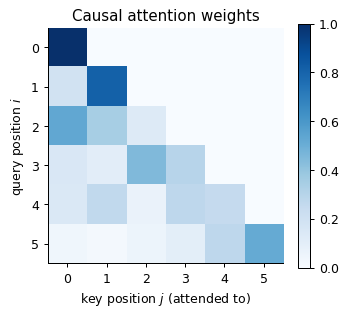

In [5]:
T_ = 6
scores = torch.randn(T_, T_)
mask = torch.triu(torch.ones(T_, T_, dtype=torch.bool), diagonal=1)
A = torch.softmax(scores.masked_fill(mask, float("-inf")), dim=-1)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(A, cmap="Blues"); plt.colorbar(im, ax=ax)
ax.set_xlabel("key position $j$ (attended to)"); ax.set_ylabel("query position $i$"); ax.set_title("Causal attention weights"); ax.grid(False)
plt.tight_layout(); plt.show()

## 7. Multi-head attention and positional encodings

**Multi-head attention.** One attention pattern per layer is limiting: a token may need to look at its subject *and* at the previous word. Run $h$ attention "heads" in parallel, each with its own smaller projections ($d_k = d/h$), concatenate, and mix:

$$
\mathrm{head}_i = \mathrm{Attention}(\mathbf{X}\mathbf{W}_Q^{(i)}, \mathbf{X}\mathbf{W}_K^{(i)}, \mathbf{X}\mathbf{W}_V^{(i)}), \qquad
\mathrm{MHA}(\mathbf{X}) = [\mathrm{head}_1,\dots,\mathrm{head}_h]\,\mathbf{W}_O .
$$

The cost is about the same as one full-width head.

**Positional information.** Because attention is permutation-equivariant (section 5), add a vector that depends on the position to each token embedding: $\mathbf{x}_t = \mathbf{E}[w_t] + \mathbf{p}_t$.
- **Learned** position embeddings, one vector per position (GPT-2; hence a maximum context of 1024).
- **Sinusoidal** (original transformer): $p_{t,2i} = \sin(t/10000^{2i/d})$, $p_{t,2i+1} = \cos(t/10000^{2i/d})$, which gives every position a unique pattern of frequencies.
- **Rotary (RoPE)**, used by most modern LLMs: rotates queries and keys by a position-dependent angle, so $\mathbf{q}^\top\mathbf{k}$ depends on the *relative* distance.

## 8. The transformer block and GPT

A GPT-style (decoder-only) transformer is: token embedding + position embedding → $N$ identical blocks → final LayerNorm → linear layer to $|V|$ logits. Each block (pre-norm version):

$$
\mathbf{X}\leftarrow\mathbf{X} + \mathrm{MHA}_{\text{causal}}\big(\mathrm{LN}(\mathbf{X})\big), \qquad
\mathbf{X}\leftarrow\mathbf{X} + \mathrm{MLP}\big(\mathrm{LN}(\mathbf{X})\big), \qquad
\mathrm{MLP}(\mathbf{x}) = \mathrm{GELU}(\mathbf{x}\mathbf{W}_1 + \mathbf{b}_1)\mathbf{W}_2 + \mathbf{b}_2 .
$$

- **Attention mixes information between positions; the MLP processes each position separately.**
- **Residual connections** (notebook 03) and **LayerNorm** (notebook 02) make deep stacks trainable.
- The output layer often reuses the embedding matrix, $\mathbf{z}_t = \mathbf{h}_t\mathbf{E}^\top$ (*weight tying*).

**Parameter count (ignoring biases and LayerNorms).** Attention has $\mathbf{W}_Q,\mathbf{W}_K,\mathbf{W}_V,\mathbf{W}_O$, each $d\times d$: $4d^2$. The MLP has hidden size $4d$: $d\cdot4d + 4d\cdot d = 8d^2$. So **$12d^2$ per block**. For GPT-2 small ($N = 12$, $d = 768$, $|V| = 50{,}257$, 1024 positions):
$$
12\cdot12\cdot768^2 \approx 84.9\text{M} \;+\; \underbrace{50{,}257\cdot768}_{\text{token emb.}}\approx 38.6\text{M} \;+\; \underbrace{1024\cdot768}_{\text{positions}}\approx 0.8\text{M} \;\approx\; 124\text{M}.
$$

In [6]:
class Block(nn.Module):
    def __init__(self, d, n_heads, dropout=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, n_heads, dropout=dropout, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d), nn.Dropout(dropout))
    def forward(self, x, return_attn=False):
        T_ = x.shape[1]
        causal = torch.triu(torch.ones(T_, T_, dtype=torch.bool, device=x.device), diagonal=1)
        h = self.ln1(x)
        a, w = self.attn(h, h, h, attn_mask=causal, need_weights=return_attn, average_attn_weights=False)
        x = x + a                                    # residual around attention
        x = x + self.mlp(self.ln2(x))                # residual around the MLP
        return (x, w) if return_attn else x

class TinyGPT(nn.Module):
    def __init__(self, vocab, d=96, n_heads=4, n_layers=3, ctx=64):
        super().__init__()
        self.ctx = ctx
        self.tok = nn.Embedding(vocab, d); self.pos = nn.Embedding(ctx, d)
        self.blocks = nn.ModuleList([Block(d, n_heads) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d); self.out = nn.Linear(d, vocab, bias=False)
        self.out.weight = self.tok.weight            # weight tying
    def forward(self, idx):                          # idx: (B, T) token ids -> (B, T, vocab) logits
        x = self.tok(idx) + self.pos(torch.arange(idx.shape[1], device=idx.device))
        for blk in self.blocks: x = blk(x)
        return self.out(self.ln(x))

d_gpt2 = 768
blk = Block(d_gpt2, 12)
n_blk = sum(p.numel() for p in blk.parameters())
print(f"one GPT-2-small block in PyTorch: {n_blk:,} parameters   (12 d^2 = {12 * d_gpt2**2:,}; the rest are biases and LayerNorms)")

one GPT-2-small block in PyTorch: 7,087,872 parameters   (12 d^2 = 7,077,888; the rest are biases and LayerNorms)


## 9. A tiny GPT, trained from scratch

To keep everything local and fast we train a **character-level** model (vocabulary = the characters of the text) on a small synthetic corpus of simple sentences, built from a tiny grammar. The model has to learn spelling, word boundaries and some grammar (which verbs go with which objects) from next-character prediction alone.

In [7]:
subjects = ["the model", "the network", "a student", "the teacher", "the tree", "the forest", "a neuron", "the optimizer"]
verbs = {"learns": ["the weights", "a pattern", "the features", "from data"],
         "predicts": ["the label", "the next word", "a probability", "the price"],
         "reduces": ["the loss", "the variance", "the error", "the bias"],
         "splits": ["the data", "the node", "the samples", "the features"]}
gen = np.random.default_rng(1); sentences = []
for _ in range(3000):
    v = gen.choice(list(verbs)); sentences.append(f"{gen.choice(subjects)} {v} {gen.choice(verbs[v])}.")
text = " ".join(sentences)
chars = sorted(set(text)); stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text])
n_tr = int(0.9 * len(data)); train_data, val_data = data[:n_tr], data[n_tr:]
print(f"{len(text):,} characters, vocabulary of {len(chars)} characters")
print(text[:200])

91,844 characters, vocabulary of 26 characters
the tree predicts the price. the model splits the data. the optimizer splits the data. a neuron predicts the next word. a neuron predicts the next word. the forest predicts a probability. the model le


parameters: 344,352
final validation loss 0.204 nats/char -> perplexity 1.23  (uniform guess: 26)


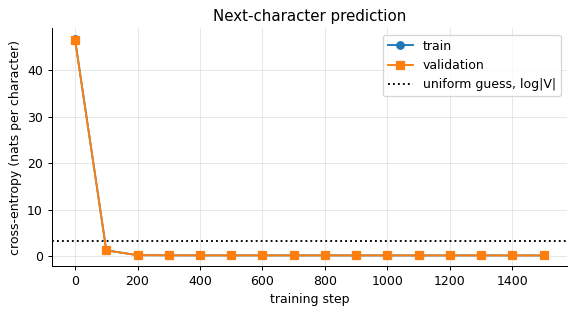

In [8]:
torch.manual_seed(0); torch.set_num_threads(4)
model = TinyGPT(len(chars))
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
ctx, B = model.ctx, 32

def get_batch(split):
    src = train_data if split == "train" else val_data
    ix = torch.randint(0, len(src) - ctx - 1, (B,))
    x = torch.stack([src[i:i + ctx] for i in ix]); y = torch.stack([src[i + 1:i + ctx + 1] for i in ix])   # targets = inputs shifted by 1
    return x, y

@torch.no_grad()
def estimate(split, n=20):
    model.eval(); losses = [F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item() for x, y in (get_batch(split) for _ in range(n))]
    model.train(); return np.mean(losses)

log = []
for step in range(1501):
    x, y = get_batch("train")
    loss = F.cross_entropy(model(x).flatten(0, 1), y.flatten())    # all T positions at once
    opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    if step % 100 == 0: log.append((step, estimate("train"), estimate("val")))
steps_, tr_, va_ = map(np.array, zip(*log))
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"final validation loss {va_[-1]:.3f} nats/char -> perplexity {np.exp(va_[-1]):.2f}  (uniform guess: {len(chars)})")

plt.figure(figsize=(6.5, 3.6))
plt.plot(steps_, tr_, "o-", label="train"); plt.plot(steps_, va_, "s-", label="validation")
plt.axhline(np.log(len(chars)), color="k", ls=":", label="uniform guess, log|V|")
plt.xlabel("training step"); plt.ylabel("cross-entropy (nats per character)"); plt.legend(); plt.title("Next-character prediction")
plt.tight_layout(); plt.show()

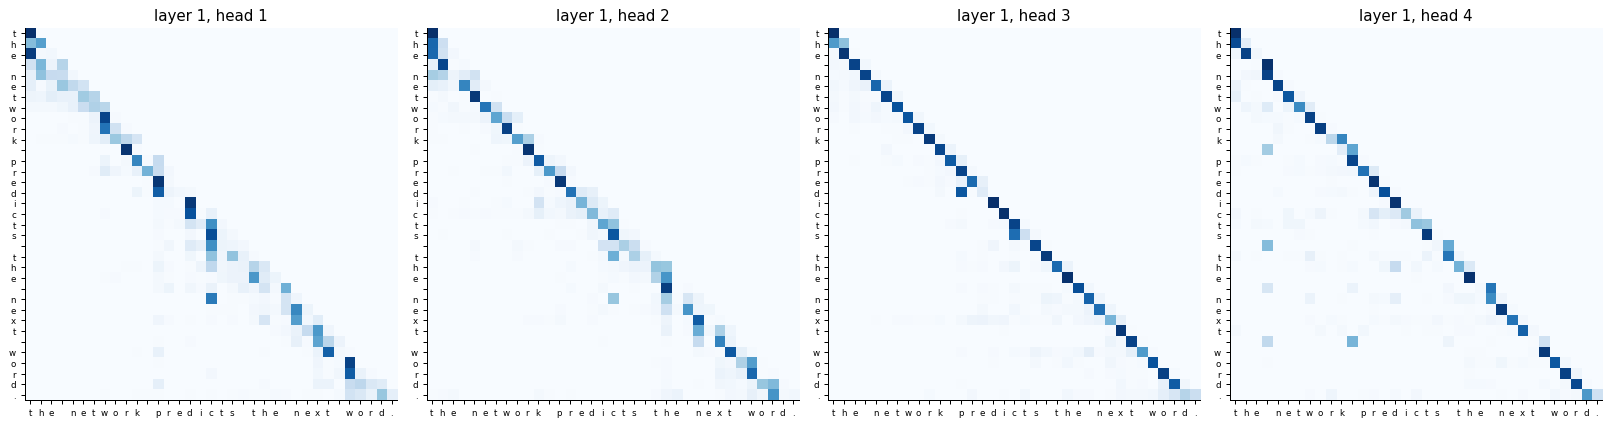

In [9]:
# Attention weights of the first layer's heads for one input
prompt = "the network predicts the next word."
idx = torch.tensor([[stoi[c] for c in prompt]])
model.eval()
with torch.no_grad():
    x = model.tok(idx) + model.pos(torch.arange(idx.shape[1]))
    _, w = model.blocks[0](x, return_attn=True)        # (1, heads, T, T)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
for h, ax in enumerate(axes):
    ax.imshow(w[0, h], cmap="Blues"); ax.set_title(f"layer 1, head {h+1}"); ax.grid(False)
    ax.set_xticks(range(len(prompt))); ax.set_xticklabels(list(prompt), fontsize=7)
    ax.set_yticks(range(len(prompt))); ax.set_yticklabels(list(prompt), fontsize=7)
plt.tight_layout(); plt.show()

Each row is one query position. The lower-triangular shape is the causal mask. Different heads learn different patterns. Here two heads attend mostly to the current character (the diagonal), and the other two spread their weight over the preceding characters of the current word: the information needed to predict how a word continues.

## 10. Decoding: from probabilities to text

At each step the model gives a distribution $\mathbf{p} = \mathrm{softmax}(\mathbf{z})$ over the next token. How we pick from it matters a lot:

- **Greedy**: take $\arg\max_k p_k$. Deterministic, often repetitive and bland; it never takes the second-best path.
- **Sampling with temperature** $\tau$: sample from $p_\tau(k) = \dfrac{e^{z_k/\tau}}{\sum_l e^{z_l/\tau}} \propto p_k^{1/\tau}$.
  - $\tau\to0$: all mass goes to the largest logit, i.e. **greedy**. *Proof:* $p_\tau(k)/p_\tau(k^*) = e^{(z_k - z_{k^*})/\tau}\to0$ for every $k$ with $z_k < z_{k^*}$.
  - $\tau = 1$: the model's own distribution.
  - $\tau\to\infty$: $z_k/\tau\to0$ for all $k$, so the distribution becomes **uniform** (random tokens).
- **Top-$k$**: keep only the $k$ most likely tokens, renormalise, sample. This cuts off the long tail of unlikely tokens that can derail a text.
- **Top-$p$ (nucleus)**: keep the smallest set of tokens whose total probability is $\ge p$ (e.g. 0.9). It adapts: few candidates when the model is confident, many when it isn't.
- **Beam search**: keep the $b$ most probable partial sequences (by total log-probability) and extend each. Good for tasks with one right answer (translation); for open-ended text it tends to be dull and repetitive.

In [10]:
@torch.no_grad()
def generate(prompt, n_new=120, temperature=1.0, top_k=None, top_p=None, seed=0):
    g = torch.Generator().manual_seed(seed)
    idx = torch.tensor([[stoi[c] for c in prompt]])
    for _ in range(n_new):
        logits = model(idx[:, -model.ctx:])[0, -1]                   # logits for the next character
        if temperature == 0:
            nxt = logits.argmax().view(1)                              # greedy
        else:
            logits = logits / temperature
            if top_k is not None:
                kth = torch.topk(logits, top_k).values[-1]; logits[logits < kth] = -float("inf")
            probs = logits.softmax(-1)
            if top_p is not None:
                sp, si = probs.sort(descending=True); keep = sp.cumsum(0) - sp < top_p
                probs = torch.zeros_like(probs).scatter(0, si[keep], sp[keep]); probs /= probs.sum()
            nxt = torch.multinomial(probs, 1, generator=g)
        idx = torch.cat([idx, nxt.view(1, 1)], dim=1)
    return "".join(itos[i] for i in idx[0].tolist())

model.eval()
for name, kw in [("greedy", dict(temperature=0)), ("τ = 0.5", dict(temperature=0.5)), ("τ = 1.0", dict(temperature=1.0)),
                 ("τ = 2.0", dict(temperature=2.0)), ("τ = 1.0, top-k = 3", dict(temperature=1.0, top_k=3)),
                 ("τ = 1.0, top-p = 0.9", dict(temperature=1.0, top_p=0.9))]:
    print(f"--- {name}\n{generate('the model', **kw)}\n")

--- greedy
the model predicts the price. the teacher splits the data. the teacher splits the data. the teacher splits the data. the teacher 

--- τ = 0.5
the model splits the data. the tree splits the features. the tree splits the data. the model predicts the next word. the teacher 



--- τ = 1.0
the model splits the data. the tree splits the features. the optimizer predicts the price. the optimizer splits the node. the mod

--- τ = 2.0
the model reduces the loss. the model splits the bias. the the tree splits the meduces the variance. the forest  teacher eeduces 



--- τ = 1.0, top-k = 3
the model splits the data. the tree splits the features. the optimizer predicts the price. the optimizer splits the data. the mod

--- τ = 1.0, top-p = 0.9
the model splits the data. the tree splits the features. the optimizer predicts the price. the optimizer splits the node. the mod



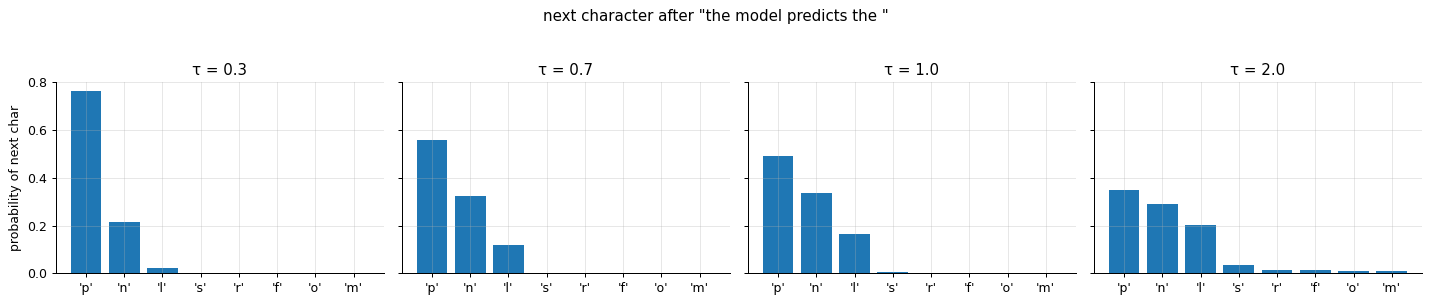

In [11]:
# How temperature reshapes one next-token distribution
with torch.no_grad():
    z = model(torch.tensor([[stoi[c] for c in "the model predicts the "]]))[0, -1]
top = torch.topk(z, 8).indices
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, tau in zip(axes, [0.3, 0.7, 1.0, 2.0]):
    p = (z / tau).softmax(-1)[top]
    ax.bar([repr(itos[i.item()]) for i in top], p.numpy()); ax.set_title(f"τ = {tau}")
axes[0].set_ylabel("probability of next char"); plt.suptitle('next character after "the model predicts the "', y=1.04)
plt.tight_layout(); plt.show()

Greedy decoding gets stuck in a loop ("the teacher splits the data." over and over). Around $\tau\approx0.5$–$1$ the text is varied and follows the grammar. At $\tau = 2$ the flattened distribution starts sampling unlikely characters, giving repeated words ("the the"), misspellings ("meduces") and verb–object pairs the grammar never produces ("splits the bias"). Higher temperatures degrade further towards random characters. Top-$k$ and top-$p$ allow $\tau = 1$ while cutting off the unlikely tail.

## 11. Encoders, decoders and modern LLMs

| | Encoder-only (BERT) | Decoder-only (GPT) | Encoder–decoder (T5, original transformer) |
|---|---|---|---|
| Attention | bidirectional (sees the whole input) | causal (past only) | encoder bidirectional; decoder causal + cross-attention to the encoder |
| Pre-training | masked-token prediction | next-token prediction | span corruption / translation |
| Good for | classification, retrieval embeddings (notebook 06), tagging | generation, chat, general-purpose LLMs | translation, summarisation |

Modern LLMs are decoder-only transformers like the one above: much larger (billions of parameters, contexts of $10^5$+ tokens), trained on trillions of tokens, then **instruction-tuned** (supervised fine-tuning on prompt/answer pairs) and aligned with human or AI feedback (RLHF, DPO). **Exposure bias**: during training the model always sees the true previous tokens, but during generation it sees its own (possibly wrong) outputs, so errors can compound over long generations.

## Summary

- A language model factorises $P(w_{1:T}) = \prod_tP(w_t\mid w_{<t})$ and is trained with next-token cross-entropy; perplexity $=\exp(J)$.
- BPE builds a sub-word vocabulary by repeatedly merging the most frequent adjacent pair.
- Attention $= \mathrm{softmax}(\mathbf{Q}\mathbf{K}^\top/\sqrt{d_k})\mathbf{V}$: a differentiable lookup; $\sqrt{d_k}$ keeps the score variance at 1; cost $O(T^2)$.
- Self-attention is permutation-equivariant, so positions must be added (learned, sinusoidal, RoPE); a causal mask allows parallel training of all next-token predictions.
- Transformer block = residual(MHA) + residual(MLP) with LayerNorm; $\approx12d^2$ parameters per block (GPT-2 small ≈ 124M).
- Decoding: greedy (τ→0), temperature sampling, top-$k$, top-$p$, beam search; the choice controls the trade-off between coherence and diversity.